# Impact of Gaming Habits and Lifestyle Factors on Student Academic Performance

***1. Problem Statement***

**Students spend considerable time on gaming and digital activities, which may affect their academic performance. This project analyzes how gaming habits, study hours, sleep patterns, attendance, stress levels, and other lifestyle factors influence student grades.**

**2. Objective of the Project**

**Analyze the relationship between gaming habits and academic performance.**
    
**Identify lifestyle factors that affect student grades.**
    
**Discover patterns using statistical analysis and data visualization.**
    
**Understand the impact of gaming addiction and device usage on academics.**
    
**Generate useful insights for students and educators.**

In [5]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
#Load Dataset 
df=pd.read_csv('Downloads/Gaming_Academic_Performance.csv')

In [7]:
# Data Understanding
df.shape

(8000, 14)

**Observation -- We have 8000 rows and 14 columns**

In [11]:
df.columns

Index(['student_id', 'age', 'gender', 'gaming_hours', 'study_hours',
       'sleep_hours', 'attendance', 'gaming_genre', 'social_activity',
       'device_usage', 'reaction_time_ms', 'addiction_score', 'stress_level',
       'grades'],
      dtype='object')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        8000 non-null   int64  
 1   age               8000 non-null   int64  
 2   gender            8000 non-null   object 
 3   gaming_hours      8000 non-null   float64
 4   study_hours       8000 non-null   float64
 5   sleep_hours       8000 non-null   float64
 6   attendance        8000 non-null   float64
 7   gaming_genre      8000 non-null   object 
 8   social_activity   8000 non-null   float64
 9   device_usage      8000 non-null   float64
 10  reaction_time_ms  8000 non-null   float64
 11  addiction_score   8000 non-null   float64
 12  stress_level      8000 non-null   object 
 13  grades            8000 non-null   float64
dtypes: float64(9), int64(2), object(3)
memory usage: 875.1+ KB


In [13]:
# Data Cleaning-Check Missing Values
df.isnull().sum()

student_id          0
age                 0
gender              0
gaming_hours        0
study_hours         0
sleep_hours         0
attendance          0
gaming_genre        0
social_activity     0
device_usage        0
reaction_time_ms    0
addiction_score     0
stress_level        0
grades              0
dtype: int64

**Observation -- Dataset contains no missing values. Hence no imputation techniques were required**

In [14]:
# Check Duplicates
df.duplicated().sum()

np.int64(0)

**Observation -- We dont have duplicate values**

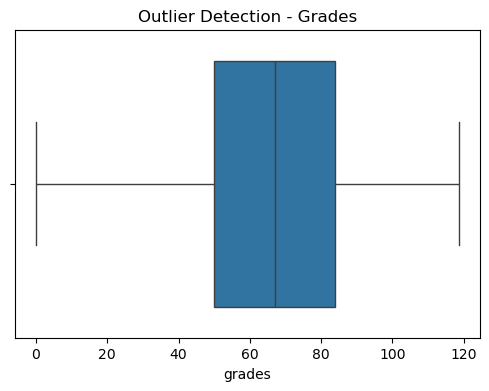

In [45]:
# Detect Outliers
# Grades
plt.figure(figsize=(6,4))
sns.boxplot(x=df['grades'])
plt.title("Outlier Detection - Grades")
plt.show()

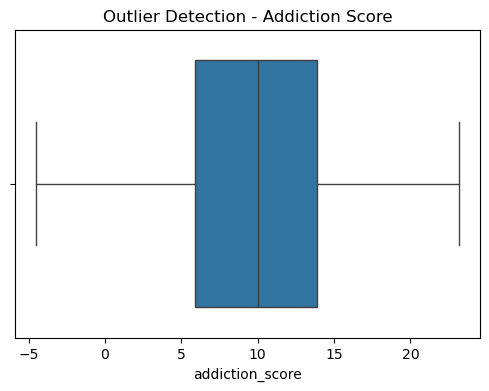

In [46]:
# Addiction Score
plt.figure(figsize=(6,4))
sns.boxplot(x=df['addiction_score'])
plt.title("Outlier Detection - Addiction Score")
plt.show()

**Observation -- No significant outliers were observed in the Grades and Addiction Score variables. Therefore, no outlier treatment was required.**

In [15]:
df.head()

,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
0,1,22,Male,7.23,8.78,6.96,91.44,FPS,3.25,9.36,235.84,14.69,Low,86.459555
1,2,19,Male,0.07,8.72,7.63,63.63,Casual,1.02,3.21,328.71,2.47,Medium,98.230000
2,3,23,Female,1.73,9.56,4.40,83.26,Casual,3.46,5.56,313.61,4.73,High,90.560000
3,4,20,Female,6.62,1.68,7.83,75.04,RPG,1.46,11.78,241.84,14.54,Low,32.670000
4,5,22,Female,5.36,5.83,5.55,65.57,FPS,1.01,8.23,249.31,12.48,Low,58.710000


In [16]:
# Descriptive Statistics
df.describe()

,student_id,age,gaming_hours,study_hours,sleep_hours,attendance,social_activity,device_usage,reaction_time_ms,addiction_score,grades
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,4000.50000,19.983625,4.085773,5.460581,6.493453,79.886525,2.507790,7.586315,271.105839,9.908492,66.180776
std,2309.54541,2.587072,2.308801,2.575787,1.442656,11.580419,1.441128,2.710035,29.440675,5.035837,22.422024
min,1.00000,16.000000,0.000000,1.000000,4.000000,60.000000,0.000000,1.100000,183.260000,-4.510000,0.000000
25%,2000.75000,18.000000,2.130000,3.240000,5.240000,69.780000,1.287500,5.560000,247.160000,5.920000,49.879843
50%,4000.50000,20.000000,4.130000,5.460000,6.505000,79.695000,2.500000,7.610000,270.475000,10.005000,67.070000
75%,6000.25000,22.000000,6.060000,7.660000,7.730000,90.100000,3.760000,9.600000,294.690000,13.860000,83.992223
max,8000.00000,24.000000,8.000000,10.000000,9.000000,100.000000,5.000000,13.950000,347.870000,23.160000,118.632936


**Key Findings from Descriptive Statistics:**

**1.Students spend more time studying (5.46 hrs) than gaming (4.09 hrs) on average.**

**2.Average sleep duration (6.49 hrs) is slightly below recommended levels.**

**3.Device usage (7.59 hrs) is significantly higher than gaming hours, suggesting substantial non-gaming screen time.**
    
**4.Attendance levels are generally good, averaging nearly 80%.**

**5.Academic performance varies considerably, with grades ranging from 0 to 118.63.**

**Non-Visual Analysis**

In [17]:
# GroupBy Analysis-Average Grades by Gender
df.groupby('gender')['grades'].mean()

gender
Female    66.579074
Male      65.857692
Other     65.315904
Name: grades, dtype: float64

**Observation -- Female students have the highest average grades (66.58), followed by male students (65.86) and other students (65.32). The difference in grades across genders is very small.**

In [18]:
# Average Grades by Gaming Genre
df.groupby('gaming_genre')['grades'].mean().sort_values(ascending=False)

gaming_genre
Casual    66.439080
FPS       66.150053
RPG       65.963455
Name: grades, dtype: float64

**Observation -- Students who play Casual games have the highest average grades (66.44), while students who play RPG games have the lowest average grades (65.96). However, the differences are very small across gaming genres.**

In [19]:
# Average Grades by Stress Level
df.groupby('stress_level')['grades'].mean()

stress_level
High      81.019857
Low       50.573928
Medium    72.731780
Name: grades, dtype: float64

**Observation -- Students with high stress levels have the highest average grades, while students with low stress levels have the lowest average grades.**

In [20]:
# Average Grades by Social Activity
df.groupby('social_activity')['grades'].mean()

social_activity
0.00    67.741394
0.01    69.448308
0.02    61.095061
0.03    66.374436
0.04    59.810133
          ...    
4.96    61.918054
4.97    64.215799
4.98    62.396885
4.99    58.398274
5.00    68.655820
Name: grades, Length: 501, dtype: float64

**Observation -- Academic performance varies across different social activity levels, but no clear trend is observed.**

In [21]:
# Average Grades by Device Usage
df.groupby('device_usage')['grades'].mean()

device_usage
1.10     62.720000
1.13     73.370000
1.16     95.380000
1.19     77.420000
1.20     86.980000
           ...    
13.84    19.830000
13.86    75.660888
13.89    21.310000
13.91     6.020000
13.95    60.138519
Name: grades, Length: 1202, dtype: float64

**Observation -- Students with very high device usage tend to have lower grades, although grades vary considerably across usage levels.**

In [22]:
# Crosstab Analysis
df['grade_category'] = pd.cut(
    df['grades'],
    bins=[0,60,80,100],
    labels=['Poor','Average','Excellent']
)

In [23]:
# Gender vs Grade Category
pd.crosstab(df['gender'],
            df['grade_category'])

grade_category,Poor,Average,Excellent
gender,,,
Female,1487,1116,1130
Male,1524,1214,1105
Other,119,88,82


**Observation -- Most students fall into the Poor grade category, regardless of gender.**

In [24]:
# Gaming Genre vs Grade Category
pd.crosstab(df['gaming_genre'],
            df['grade_category'])

grade_category,Poor,Average,Excellent
gaming_genre,,,
Casual,933,706,711
FPS,1249,970,922
RPG,948,742,684


**Observation -- FPS games have the highest number of students across all grade categories.**

In [25]:
# Stress Level vs Grade Category
pd.crosstab(df['stress_level'],
            df['grade_category'])

grade_category,Poor,Average,Excellent
stress_level,,,
High,72,379,537
Low,1919,468,320
Medium,1139,1571,1460


**Observation -- Students with high stress levels are more concentrated in the Excellent category, while students with low stress levels are mostly in the Poor category.**

In [26]:
# Pivot Table Analysis-Average Grades by Gaming Genre and Gender
pd.pivot_table(
    df,
    values='grades',
    index='gaming_genre',
    columns='gender',
    aggfunc='mean'
)

gender,Female,Male,Other
gaming_genre,,,
Casual,66.918002,66.087437,64.944100
FPS,66.567202,65.535770,69.058082
RPG,66.251854,66.055414,60.947393


**Observation -- Average grades are similar across gaming genres and genders, with only minor variations.**

In [27]:
# Average Grades by Stress Level and Gender
pd.pivot_table(
    df,
    values='grades',
    index='stress_level',
    columns='gender',
    aggfunc='mean'
)

gender,Female,Male,Other
stress_level,,,
High,81.056296,81.089181,79.493148
Low,51.314847,49.831808,50.506896
Medium,73.260589,72.334265,71.336130


**Observation -- Across all genders, students with higher stress levels achieve higher average grades.**

In [28]:
# Average Addiction Score by Gaming Genre
pd.pivot_table(
    df,
    values='addiction_score',
    index='gaming_genre',
    aggfunc='mean'
)

,addiction_score
gaming_genre,
Casual,9.989834
FPS,9.815930
RPG,9.949759


**Observation -- Average addiction scores are nearly the same across all gaming genres.**

**Correlation Analysis**

In [29]:
corr = df.corr(numeric_only=True)
corr

,student_id,age,gaming_hours,study_hours,sleep_hours,attendance,social_activity,device_usage,reaction_time_ms,addiction_score,grades
student_id,1.000000,0.005701,0.013262,-0.005397,0.003962,-0.004271,0.001827,0.015397,-0.008136,0.003835,-0.012087
age,0.005701,1.000000,0.003503,0.011244,0.008365,0.010693,0.008388,-0.000389,-0.004007,0.001377,0.008052
gaming_hours,0.013262,0.003503,1.000000,-0.010558,0.002699,-0.000337,0.006929,0.847920,-0.939266,0.909044,-0.551312
study_hours,-0.005397,0.011244,-0.010558,1.000000,0.018629,-0.008569,-0.010709,-0.011092,0.011824,-0.002204,0.733132
sleep_hours,0.003962,0.008365,0.002699,0.018629,1.000000,-0.030495,-0.022627,0.008339,-0.008932,-0.002034,0.250298
attendance,-0.004271,0.010693,-0.000337,-0.008569,-0.030495,1.000000,0.007738,-0.004957,0.000360,0.000034,0.130842
social_activity,0.001827,0.008388,0.006929,-0.010709,-0.022627,0.007738,1.000000,0.005501,-0.007969,0.009741,-0.018717
device_usage,0.015397,-0.000389,0.847920,-0.011092,0.008339,-0.004957,0.005501,1.000000,-0.791445,0.847297,-0.468472
reaction_time_ms,-0.008136,-0.004007,-0.939266,0.011824,-0.008932,0.000360,-0.007969,-0.791445,1.000000,-0.849808,0.517340
addiction_score,0.003835,0.001377,0.909044,-0.002204,-0.002034,0.000034,0.009741,0.847297,-0.849808,1.000000,-0.495055


**Observations:**

**1.Study hours (0.733) have the strongest positive correlation with grades, indicating that students who study more tend to achieve higher academic performance.**

**2.Gaming hours (-0.551) and addiction score (-0.495) show a moderate negative correlation with grades, suggesting that excessive gaming and gaming addiction are associated with lower academic performance.**

**3.Device usage (-0.468) is negatively correlated with grades, indicating that higher device usage may adversely affect academic outcomes.**

**4.Sleep hours (0.250) and attendance (0.131) have a positive correlation with grades, suggesting that adequate sleep and regular attendance contribute to better academic performance.**

**Visual Analysis**

**1.Univariate Analysis**

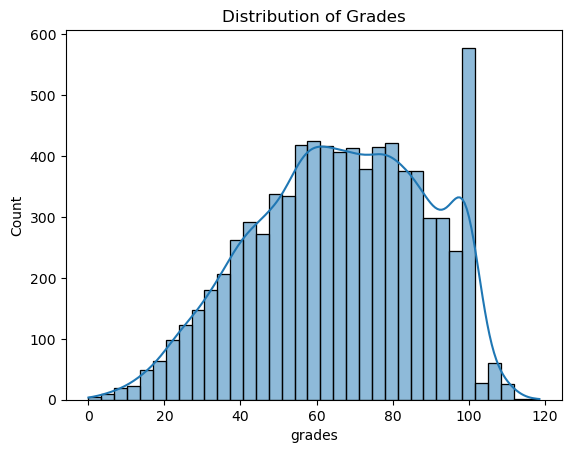

In [31]:
# Grades Distribution
sns.histplot(df['grades'], kde=True)
plt.title("Distribution of Grades")
plt.show()

**Obsrvation -- Most students scored between 50 and 90 marks, with the highest concentration around 60–80 marks. The distribution indicates that the majority of students achieved average to good academic performance, while very few students scored extremely low or extremely high marks.**

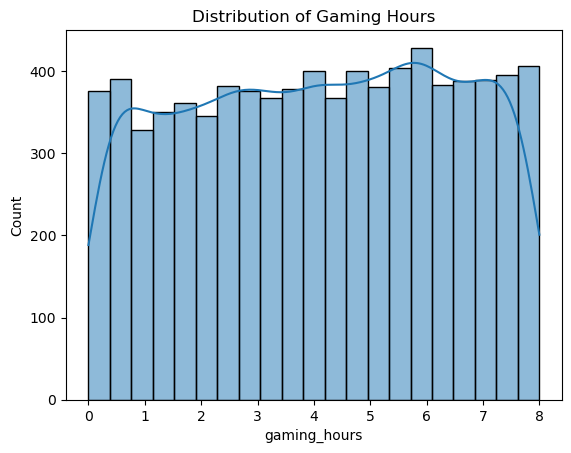

In [32]:
# Gaming Hours Distribution
sns.histplot(df['gaming_hours'], kde=True)
plt.title("Distribution of Gaming Hours")
plt.show()

**Observation -- Gaming hours are fairly evenly distributed between 0 and 8 hours, with most students spending around 4–6 hours per day on gaming.**

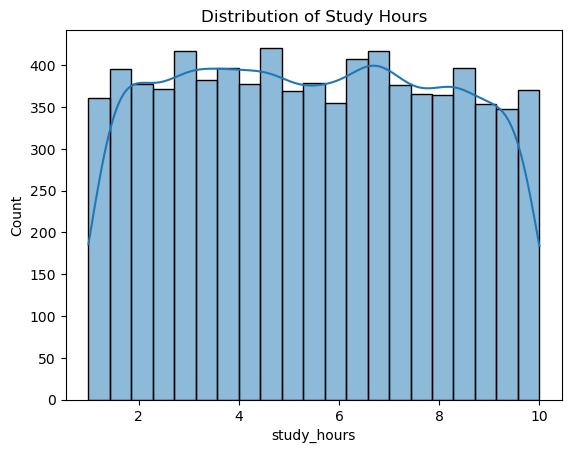

In [33]:
# Study Hours Distribution
sns.histplot(df['study_hours'], kde=True)
plt.title("Distribution of Study Hours")
plt.show()

**Observation -- Study hours are distributed between 1 and 10 hours, with most students studying around 5–7 hours per day.**

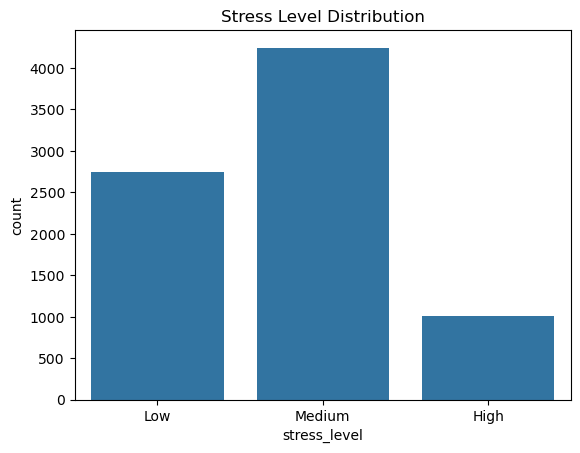

In [34]:
# Stress Level Distribution
sns.countplot(x='stress_level', data=df)
plt.title("Stress Level Distribution")
plt.show()

**Observation -- Medium stress is the most common stress level among students, followed by Low stress. Only a smaller proportion of students fall into the High stress category, indicating that most students experience moderate levels of academic or lifestyle-related stress.**

**Bivariate Analysis (Two Variables)**

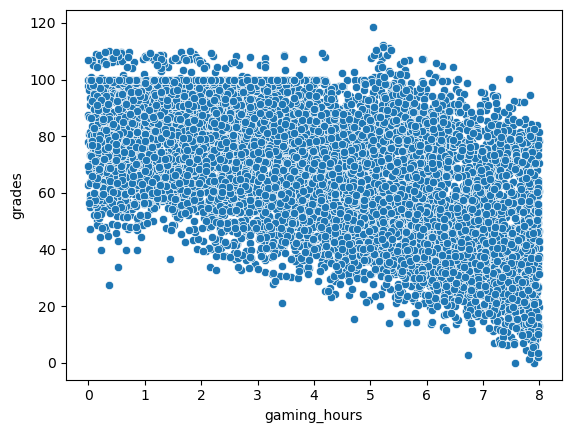

In [35]:
# Gaming Hours vs Grades
sns.scatterplot(x='gaming_hours',
                y='grades',
                data=df)
plt.show()

**Observation -- A clear negative relationship is observed between gaming hours and grades. As gaming hours increase, student grades tend to decrease.**           

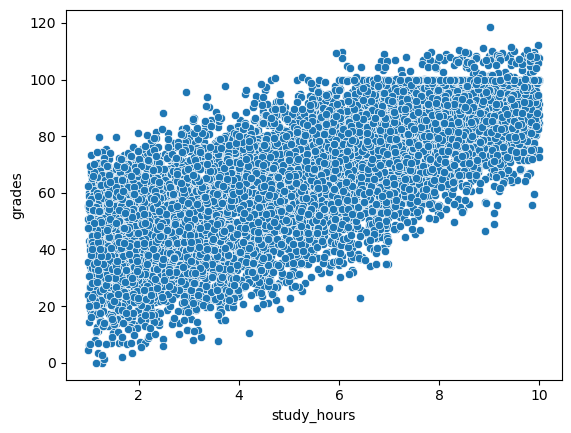

In [36]:
# Study Hours vs Grades
sns.scatterplot(x='study_hours',
                y='grades',
                data=df)
plt.show()

**Observation -- A strong positive relationship exists between study hours and grades. Students who study more tend to achieve higher academic performance.**

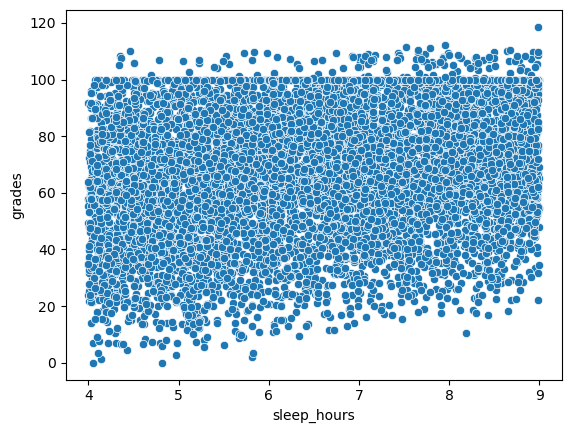

In [37]:
# Sleep Hours vs Grades
sns.scatterplot(x='sleep_hours',
                y='grades',
                data=df)
plt.show()

**Observation -- Students who sleep for longer durations generally achieve better grades, indicating a positive relationship between sleep and academic performance.**

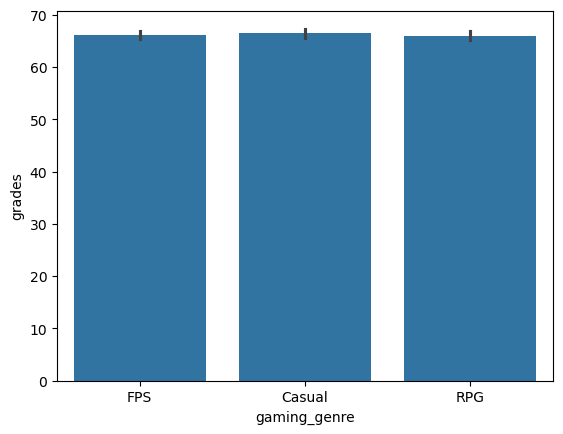

In [38]:
# Gaming Genre vs Grades
sns.barplot(x='gaming_genre',
            y='grades',
            data=df)
plt.show()

**Observation -- Average grades are very similar across FPS, Casual, and RPG gaming genres, indicating that gaming genre has minimal impact on academic performance.**

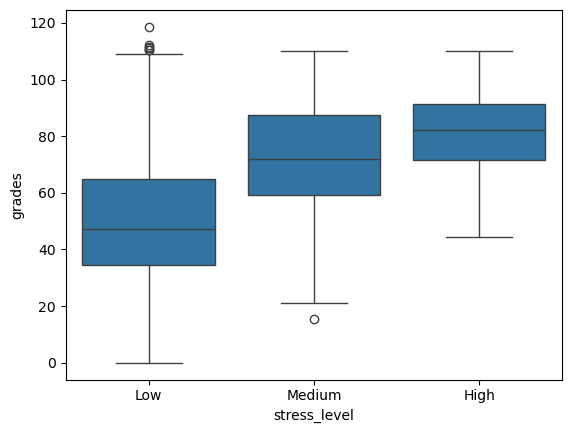

In [39]:
# Stress Level vs Grades
sns.boxplot(x='stress_level',
            y='grades',
            data=df)
plt.show()

**Observation -- Students with high stress levels have the highest median grades, while students with low stress levels have the lowest median grades. This suggests that academically focused students may experience higher stress.**

**Multivariate Analysis (3+ Variables)**

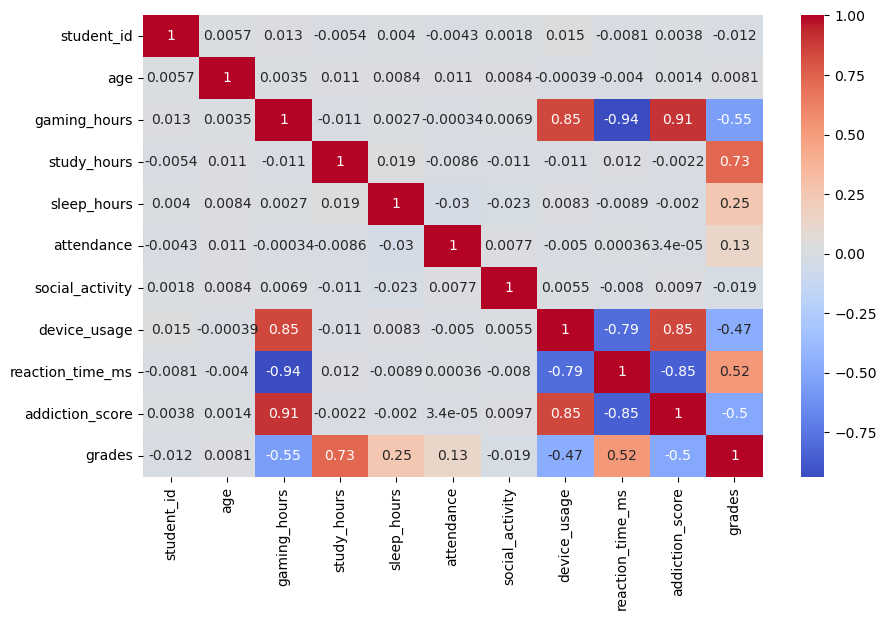

In [40]:
# Correlation Heatmap
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.show()

**Observation -- Study hours show the strongest positive correlation with grades (0.73), while gaming hours (-0.55), addiction score (-0.50), and device usage (-0.47) show negative correlations with grades.**

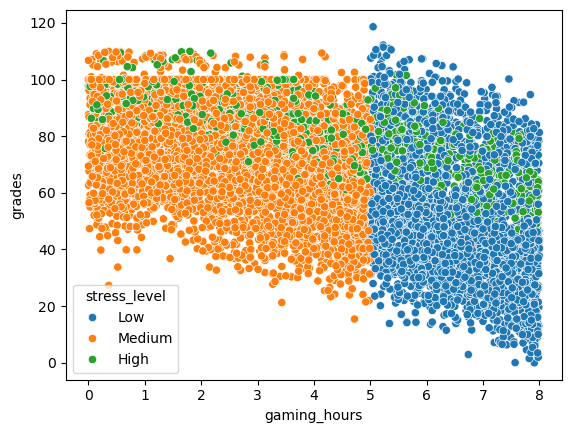

In [41]:
# Gaming Hours vs Grades by Stress Level
sns.scatterplot(
    x='gaming_hours',
    y='grades',
    hue='stress_level',
    data=df
)
plt.show()

**Observation -- Students with lower gaming hours generally achieve better grades across all stress levels. High-stress students are more concentrated in the higher grade range.**

**Advanced Statistics**

**Pearson Correlation Test**

Measures whether the relationship between two variables is statistically significant.

In [42]:
from scipy.stats import pearsonr

corr,p = pearsonr(
    df['gaming_hours'],
    df['grades']
)

print("Correlation:",corr)
print("P-value:",p)

Correlation: -0.5513117134349623
P-value: 0.0


**Observation -- There is a moderate negative correlation between gaming hours and grades. Since the p-value is less than 0.05, the relationship is statistically significant, indicating that increased gaming hours are associated with lower academic performance.**

**------------------------------------------------------------------**

**Final Insights**

**1.Study hours are the strongest positive factor influencing academic performance.**

**2.Gaming hours, addiction score, and device usage negatively affect grades.**
    
**3.Adequate sleep contributes positively to academic success.**
    
**4.Stress levels show a positive association with grades in this dataset, suggesting that higher-performing students may experience greater academic pressure.**
    
**5.Gaming genre has little impact on academic performance compared to gaming duration and study habits.**

**-------------------------------------------------------------**

**Recommendations**
  
**1.Students should maintain a balance between gaming and study time.**

**2.Increasing study hours can significantly improve academic performance.**

**3.Excessive gaming and device usage should be reduced to avoid negative academic outcomes.**

**4.Students should maintain healthy sleep habits to support learning and concentration.**

**5.Educational institutions should create awareness about gaming addiction and effective time management.**

**-----------------------------------------------------------------**

**Conclusion**

**This study examined the impact of gaming habits and lifestyle factors on student academic performance. The analysis revealed that study hours have the strongest positive influence on grades, while gaming hours, addiction scores, and device usage negatively affect academic outcomes. Sleep duration contributes positively to performance, whereas gaming genre has minimal impact. Overall, maintaining balanced gaming habits, healthy sleep patterns, and effective study routines can help students achieve better academic results.**
